In [1]:
import osmnx as ox
import networkx as nx
import pandas as pd
import json
import matplotlib.pyplot as plt

In [2]:
# Coordinates: (lat, lon)
HCMUT = (10.7722, 106.6579)
BEN_THANH = (10.7725, 106.6983)


margin = 0.015

south = min(HCMUT[0], BEN_THANH[0]) - margin
north = max(HCMUT[0], BEN_THANH[0]) + margin
west  = min(HCMUT[1], BEN_THANH[1]) - margin
east  = max(HCMUT[1], BEN_THANH[1]) + margin

# OSMnx v2: bbox = (left, bottom, right, top)
bbox = (west, south, east, north)


In [3]:
# Download road graph

G = ox.graph_from_bbox(
    bbox,
    network_type="drive",
    simplify=True,
    retain_all=False
)


In [20]:
G.adjacency().__next__()

(366368680,
 {6637725827: {0: {'osmid': 1486236792,
    'highway': 'secondary_link',
    'oneway': False,
    'reversed': False,
    'length': np.float64(5.900371819741878)}},
  6251877929: {0: {'osmid': 468724786,
    'highway': 'tertiary',
    'lanes': '2',
    'name': 'Đường Hàn Hải Nguyên',
    'oneway': False,
    'reversed': True,
    'length': np.float64(84.54787730294001),
    'geometry': <LINESTRING (106.651 10.758, 106.651 10.758, 106.651 10.758, 106.651 10.758,...>}}})

In [4]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 3902
Number of edges: 9118


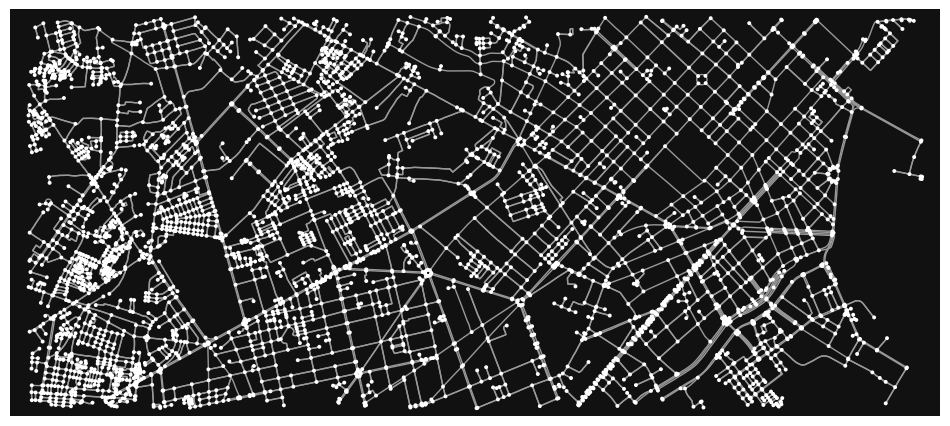

In [5]:
fig, ax = ox.plot_graph(
    G,
    figsize=(12, 12),
    node_size=8,
    edge_linewidth=1,
    show=True,
    close=False
)

plt.show()

In [7]:
import folium
import osmnx as ox

# Convert graph sang GeoDataFrame
nodes, edges = ox.graph_to_gdfs(G)

m = folium.Map(
    location=BEN_THANH,
    zoom_start=16,
    tiles=None
)

folium.TileLayer(
    tiles="Esri.WorldStreetMap",
    name="Esri Street Map"
).add_to(m)

# Vẽ edges
folium.GeoJson(
    edges[["geometry"]].to_json(),
    name="Road edges",
    style_function=lambda x: {
        "color": "blue",
        "weight": 2,
        "opacity": 0.7
    }
).add_to(m)

# Vẽ nodes
for node_id, row in nodes.iterrows():
    folium.CircleMarker(
        location=[row["y"], row["x"]],
        radius=2,
        color="red",
        fill=True,
        fill_opacity=0.8,
        popup=str(node_id)
    ).add_to(m)

# Marker 2 địa điểm lớn
folium.Marker(
    location=HCMUT,
    popup="HCMUT",
    icon=folium.Icon(color="green")
).add_to(m)

folium.Marker(
    location=BEN_THANH,
    popup="Ben Thanh Market",
    icon=folium.Icon(color="orange")
).add_to(m)

folium.LayerControl().add_to(m)

m.save("outputs/map.html")

In [11]:
nodes

,y,x,street_count,highway,railway,ref,geometry
osmid,,,,,,,
366368680,10.757866,106.651247,4,NaN,NaN,NaN,POINT (106.65125 10.75787)
366370087,10.757800,106.643854,3,NaN,NaN,NaN,POINT (106.64385 10.7578)
366370617,10.764536,106.671241,3,NaN,NaN,NaN,POINT (106.67124 10.76454)
366370772,10.758225,106.646309,3,NaN,NaN,NaN,POINT (106.64631 10.75822)
366370884,10.779642,106.644526,3,NaN,NaN,NaN,POINT (106.64453 10.77964)
...,...,...,...,...,...,...,...
13741907926,10.766825,106.690750,3,NaN,NaN,NaN,POINT (106.69075 10.76683)
13741907927,10.766837,106.690579,1,NaN,NaN,NaN,POINT (106.69058 10.76684)
13741907929,10.766723,106.690831,1,NaN,NaN,NaN,POINT (106.69083 10.76672)
